# 🕌 KHALEEJI-MIND
## A Gulf Arabic Social Cognition Benchmark — Interactive Theory of Mind Evaluation Pipeline

> **Course:** CS-UH 3260 · Artificial Social Intelligence · NYU Abu Dhabi  
> **Dataset:** `KHALEEJI_MIND_balanced_80_cleaned.csv` (80 scenarios, 5 norm categories)

---

### Pipeline Overview

This notebook runs the full KHALEEJI-MIND evaluation pipeline in the following order:

| Step | Section | Description |
|------|---------|-------------|
| 0 | Setup | Install packages and import libraries |
| 1 | Configuration | API keys and model IDs |
| 2 | Data Loading | Load CSV, clean columns, inspect dataset |
| 3 | Preprocessing | Normalize text, build zero-shot prompts |
| 4 | Model Evaluation | Random baseline + GPT-4 + Gemini (zero-shot) |
| 5 | Main Results | Accuracy table across categories, language, ToM order |
| 6 | Chain-of-Thought | CoT prompting evaluation |
| 7 | Cultural Bias | Norm-in-context and western-framing probes |
| 8 | Visualisation | Accuracy bar charts |
| 9 | Error Analysis | Western-centric error rate, severity breakdown |
| 10 | Norm Diagnostic | Zero-shot vs norm-in-context deep comparison |
| 11 | Save Results | Export results CSV |


## Step 0 — Setup

Upgrades `numpy` first (avoids binary incompatibility errors in Colab), then installs all required packages.  
**After running this cell, restart the runtime before continuing.**


In [ ]:
import sys
import subprocess

# Upgrade numpy first to avoid binary incompatibility with other packages
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "numpy>=2.0", "--upgrade"],
    check=True
)

# Install all other required packages
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "openai", "google-generativeai",
     "pandas", "matplotlib", "seaborn",
     "scipy", "scikit-learn", "statsmodels"],
    check=True
)

print("✅ All packages installed.")
print("→ If running in Colab: Runtime → Restart session, then run from Step 1.")


✅ All packages installed.
→ If running in Colab: Runtime → Restart session, then run from Step 1.


## Step 1 — Configuration

Set your API keys and model identifiers here.

- **OpenRouter** is used to call all three models via a unified API endpoint.
- **GPT-4** is accessed via `openai/gpt-4`.
- **Gemini** is accessed via `google/gemini-2.5-flash`.
- **Mistral-7B** is accessed via `mistralai/mistral-7b-instruct-v0.1` as the open-source baseline.
- No mock fallback — all results are real API calls.

In [ ]:

# ── API Keys ─────────────────────────────────────────────────
import os
from getpass import getpass

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY") or getpass("Enter OpenRouter API key: ")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY") or getpass("Enter Gemini API key: ")

os.environ["OPENROUTER_API_KEY"] = OPENROUTER_API_KEY
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

# ── Model IDs on OpenRouter ───────────────────────────────────
GPT4_MODEL   = "openai/gpt-4"
GEMINI_MODEL = "google/gemini-2.5-flash"
LLAMA_MODEL = "mistralai/mistral-7b-instruct-v0.1"

print("✅ Configuration ready.")
print(f"   GPT-4 model     : {GPT4_MODEL}")
print(f"   Gemini model    : {GEMINI_MODEL}")
print(f"   Mistral-7B model : {LLAMA_MODEL}")

Enter OpenRouter API key: ··········
Enter Gemini API key: ··········
✅ Configuration ready.
   GPT-4 model     : openai/gpt-4
   Gemini model    : google/gemini-2.5-flash
   Mistral-7B model : mistralai/mistral-7b-instruct-v0.1


## Step 2 — Data Loading

Loads the cleaned KHALEEJI-MIND dataset and prepares all columns for evaluation.

### What happens here
- Reads the CSV from the path you specify in `CSV_PATH`
- Renames columns to short, consistent internal names
- Normalises the `language` field (`ENG/AR` → `BILINGUAL`)
- Maps `tom_order` strings (`"first"` / `"second"`) to integers (1 / 2)
- Bundles the four answer options into a single `options` dict per row
- Uses the pre-existing `question_text` column directly (no reconstruction needed)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# ── Set path to your CSV ──────────────────────────────────────
# If running locally, set this to the file's absolute or relative path.
# If running in Colab with Google Drive, mount first and use the Drive path.
CSV_PATH = "/content/drive/MyDrive/ASI_FINAL_PROJECT/KHALEEJI_MIND_balanced_80_cleaned.csv"

df = pd.read_csv(CSV_PATH)

# Clean column names
df.columns = df.columns.str.strip()

# Rename only if old column names exist
df = df.rename(columns={
    "scenario_id": "id",
    "scenario_text": "scenario",
    "question_text": "question",
    "correct_answer": "correct",
    "common_western_misreading": "western_distractor",
})

# Clean answer labels
df["correct"] = df["correct"].astype(str).str.strip().str.upper()

# Normalize language labels
df["language"] = df["language"].replace({
    "ENG/AR": "BILINGUAL",
    "EN/AR": "BILINGUAL"
})

# Handle ToM order safely
# Handle ToM order safely
df["tom_order"] = df["tom_order"].astype(str).str.strip()
df["tom_order"] = df["tom_order"].replace({
    "first": "1",
    "second": "2",
    "First": "1",
    "Second": "2"
})
df["tom_order"] = pd.to_numeric(df["tom_order"], errors="coerce").astype("Int64")

# Clean severity
df["severity"] = pd.to_numeric(df["severity"], errors="coerce").astype("Int64")

# Bundle answer options into a dict per row
df["options"] = df.apply(
    lambda r: {
        "A": r["option_A"],
        "B": r["option_B"],
        "C": r["option_C"],
        "D": r["option_D"]
    },
    axis=1
)

print(f"✅ Loaded {len(df)} scenarios  |  {df['norm_category'].nunique()} norm categories")

print("\nnorm_category distribution:")
print(df["norm_category"].value_counts().to_string())

print("\nlanguage distribution:")
print(df["language"].value_counts().to_string())

print("\ntom_order distribution:")
print(df["tom_order"].value_counts().sort_index().to_string())

print("\ncorrect_answer distribution:")
print(df["correct"].value_counts().sort_index().to_string())

print("\nseverity distribution:")
print(df["severity"].value_counts().sort_index().to_string())


✅ Loaded 80 scenarios  |  5 norm categories

norm_category distribution:
norm_category
diyafa                  23
religious_observance    16
hierarchy               15
gender_interaction      15
community_obligation    11

language distribution:
language
EN           30
BILINGUAL    26
AR           24

tom_order distribution:
tom_order
1    41
2    39

correct_answer distribution:
correct
A    20
B    20
C    20
D    20

severity distribution:
severity
0    26
2     9
3    21
4    14
5    10


### Dataset Balance Summary

The final dataset contains **80 scenarios** across **5 norm categories**. The largest category is **diyafa** with 23 scenarios, which is expected because hospitality includes many detailed Emirati سنع practices such as qahwa serving, majlis etiquette, guest reception, and visit-closing cues. The other categories are also represented: religious observance has 16 scenarios, hierarchy and gender interaction each have 15, and community obligation has 11.

The language distribution is reasonably balanced across **English (31)**, **bilingual/code-switched scenarios (25)**, and **Arabic (24)**. This supports evaluation across different linguistic contexts, including the mixed Arabic-English settings common in Gulf communication.

The Theory of Mind split is also balanced, with **41 first-order** and **39 second-order** scenarios. This means the benchmark tests both direct belief inference and more complex reasoning about one person’s understanding of another person’s belief.

Finally, the correct answers are perfectly balanced, with **20 answers each for A, B, C, and D**. This reduces answer-position bias and makes the evaluation more reliable.

## Step 2b — Dataset Overview

A structured summary of the KHALEEJI-MIND benchmark dataset.

### What is KHALEEJI-MIND?

KHALEEJI-MIND is a Theory of Mind (ToM) evaluation benchmark designed to test whether large language models can correctly interpret the mental states, beliefs, and intentions of characters operating within **Gulf Arabic social norms**. Each scenario presents a culturally-specific social situation and asks the model to identify what a focal character truly thinks or feels — while avoiding a plausible Western-centric misreading.

### Dataset Properties

| Property | Value |
|----------|-------|
| Total scenarios | **80** |
| Norm categories | **5** (diyafa, hierarchy, gender_interaction, religious_observance, community_obligation) |
| Languages | EN · AR · BILINGUAL |
| ToM Order 1 (direct mental state) | 41 scenarios |
| ToM Order 2 (belief about belief) | 39 scenarios |
| Answer options per scenario | 4 (A / B / C / D) |
| Random chance baseline | 25% |
| Severity range | 0 (no violation) → 5 (severe violation) |

### Norm Categories

| Category | Count | Description |
|----------|-------|-------------|
| `diyafa` | 23 | Hospitality and guest reception norms |
| `hierarchy` | 15 | Age, rank, and status-based interaction rules |
| `religious_observance` | 16 | Islamic practice and observance etiquette |
| `gender_interaction` | 15 | Gender-separated space and modesty norms |
| `community_obligation` | 11 | Collective duty, neighbourhood, and السنع etiquette |

### Severity Scale

Each scenario carries a `severity` score indicating how serious the social violation in the scenario is:

| Score | Meaning |
|-------|---------|
| 0 | No real violation — character merely misreads a cultural cue |
| 2 | Minor norm breach with minimal social consequence |
| 3 | Moderate violation — socially noticeable and awkward |
| 4 | Serious breach — damages relationships or reputation |
| 5 | Severe violation — significant social or religious transgression |

### Key Design Choices

- Every scenario includes **one culturally correct answer** and **one Western-centric distractor** designed to reflect how a non-Khaleeji observer would misinterpret the situation.
- Scenarios span **first-order** ToM (what does X think?) and **second-order** ToM (what does X think Y believes?).
- Arabic and bilingual scenarios test whether models maintain cultural accuracy across languages.

In [ ]:
# ── Severity distribution ──────────────────────────────────
print("Severity distribution:")
print(df["severity"].value_counts().sort_index().to_string())
print()

# ── Severity by norm category ──────────────────────────────
print("Mean severity by norm category:")
print(df.groupby("norm_category")["severity"].mean().round(2).sort_values(ascending=False).to_string())
print()

# ── ToM order by category ─────────────────────────────────
print("ToM order breakdown by norm category:")
print(df.groupby(["norm_category", "tom_order"]).size().unstack(fill_value=0).to_string())
print()

# ── Language by category ──────────────────────────────────
print("Language distribution by norm category:")
print(df.groupby(["norm_category", "language"]).size().unstack(fill_value=0).to_string())


Severity distribution:
severity
0    26
2     9
3    21
4    14
5    10

Mean severity by norm category:
norm_category
community_obligation    3.18
religious_observance    2.62
diyafa                  2.26
hierarchy                2.2
gender_interaction      1.67

ToM order breakdown by norm category:
tom_order              1   2
norm_category               
community_obligation   4   7
diyafa                12  11
gender_interaction     6   9
hierarchy              9   6
religious_observance  10   6

Language distribution by norm category:
language              AR  BILINGUAL  EN
norm_category                          
community_obligation   2          7   2
diyafa                 3          9  11
gender_interaction     8          4   3
hierarchy              5          4   6
religious_observance   6          2   8


### Severity and Cross-Category Analysis

The severity distribution shows that many scenarios are coded as **0**, meaning no local norm is directly violated; instead, the scenario tests whether an outsider or model misreads a culturally appropriate Emirati behavior. Higher severity values are reserved for cases where an actual breach of سنع occurs, such as mishandling qahwa, disrespecting elders, or violating hospitality expectations.

The highest average severity appears in **diyafa** and **religious observance**, which makes sense because these categories often involve visible social duties, guest treatment, and ritual expectations. A mistake in these areas can create stronger social consequences. In contrast, **gender interaction** and **hierarchy** have lower average severity because many scenarios in these categories focus on outsiders misinterpreting correct local behavior rather than someone committing a serious breach.

The Theory of Mind distribution remains balanced within the dataset, with both first-order and second-order reasoning represented across all norm categories. The language breakdown also shows useful variation: English, Arabic, and bilingual/code-switched scenarios appear across categories, allowing the benchmark to test cultural reasoning across different linguistic contexts.

In [ ]:
print("Rows:", len(df))

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nCorrect answer distribution:")
print(df["correct"].value_counts())

print("\nLanguage distribution:")
print(df["language"].value_counts())

print("\nNorm category distribution:")
print(df["norm_category"].value_counts())

print("\nToM order distribution:")
print(df["tom_order"].value_counts())

print("\nSeverity distribution:")
print(df["severity"].value_counts().sort_index())

# Check duplicate IDs
duplicates = df[df["id"].duplicated(keep=False)]
print("\nDuplicate IDs:")
print(duplicates[["id", "scenario"]])

# Check invalid answers
invalid_answers = df[~df["correct"].isin(["A", "B", "C", "D"])]
print("\nInvalid correct answer rows:")
print(invalid_answers[["id", "correct"]])

# Check severity is valid 0–5
valid_severity = [0, 1, 2, 3, 4, 5]
bad_severity = df[~df["severity"].isin(valid_severity)]

print("\nRows with invalid severity:", len(bad_severity))
bad_severity[["id", "norm_category", "severity", "violated_norm"]]

Rows: 80

Columns:
['id', 'norm_category', 'tom_order', 'language', 'scenario', 'question', 'character', 'option_A', 'option_B', 'option_C', 'option_D', 'correct', 'violated_norm', 'severity', 'cultural_explanation', 'western_distractor', 'options']

Missing values:
id                      0
norm_category           0
tom_order               0
language                0
scenario                0
question                0
character               0
option_A                0
option_B                0
option_C                0
option_D                0
correct                 0
violated_norm           0
severity                0
cultural_explanation    0
western_distractor      0
options                 0
dtype: int64

Correct answer distribution:
correct
C    20
D    20
A    20
B    20
Name: count, dtype: int64

Language distribution:
language
EN           30
BILINGUAL    26
AR           24
Name: count, dtype: int64

Norm category distribution:
norm_category
diyafa                  23
relig

,id,norm_category,severity,violated_norm


The dataset has 80 complete scenarios with no missing values, duplicates, or invalid labels. Answers are balanced across A–D, and ToM order is nearly balanced. The dataset covers English, Arabic, and bilingual scenarios across five Emirati norm categories. Severity uses a 0–5 scale, where 0 means misunderstanding only and higher values indicate stronger social consequences.

## Step 2c — Map Western Distractor to Answer Letter

Each scenario has a `western_distractor` field containing the text of the answer option that reflects a typical Western misreading of the situation. This step identifies **which letter (A/B/C/D)** that distractor corresponds to in each row by matching it against the four option texts.

This letter is used later in the error analysis to measure how often models choose the Western-centric wrong answer specifically.


In [ ]:
def find_western_letter(row):
    """Match the western_distractor text to one of the four option letters."""
    misreading = str(row["western_distractor"]).strip().lower()
    best_letter = "A"
    best_score  = 0
    for letter in ["A", "B", "C", "D"]:
        option_text = str(row[f"option_{letter}"]).strip().lower()
        # Score by shared meaningful words (length > 4 to skip stopwords)
        words = [w for w in option_text.split() if len(w) > 4]
        score = sum(1 for w in words if w in misreading)
        if score > best_score:
            best_score  = score
            best_letter = letter
    return best_letter

df["western_letter"] = df.apply(find_western_letter, axis=1)

print("Western distractor letter distribution:")
print(df["western_letter"].value_counts().to_string())
print()
print("✅ Western letter mapping complete.")


Western distractor letter distribution:
western_letter
A    37
B    20
C    12
D    11

✅ Western letter mapping complete.


### Western Distractor Mapping

The **Western distractor** refers to the incorrect answer option that best represents a likely non-local or Western-centric misunderstanding of the scenario. In other words, it is the answer a person unfamiliar with Emirati سنع might choose because they interpret the situation through a different cultural framework.

This step maps the written `western_distractor` explanation to one of the four answer options: **A, B, C, or D**. The function compares the words in each option with the text of the Western misreading and selects the option with the strongest word overlap. This allows the dataset to track not only the correct answer, but also which incorrect option reflects the most likely cultural misunderstanding.

The Western distractor does not need to be balanced across A, B, C, and D because it is not the correct answer key. It is an additional analysis label used to study whether models are attracted to culturally external interpretations.

## Step 3 — Text Preprocessing & Prompt Building

Prepares each scenario for model evaluation.

### What happens here
- **Arabic normalisation**: removes diacritics (tashkeel) and collapses whitespace — models do not need vocalisation marks and they can cause inconsistent tokenisation.
- **English normalisation**: collapses extra whitespace only.
- **Prompt serialisation**: each scenario is formatted into a fixed zero-shot prompt template.

The prompt format is:
```
Scenario: <scenario text>

Question: <question text>

A) <option A>
B) <option B>
C) <option C>
D) <option D>

Answer with only the letter A, B, C, or D.
Answer:
```


In [ ]:
import re
import unicodedata

def normalize_arabic(text):
    """Remove Arabic diacritics and collapse whitespace."""
    text = unicodedata.normalize("NFC", text)
    # Strip tashkeel (diacritic marks)
    text = re.sub(
        "[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06DC\u06DF-\u06E4\u06E7-\u06ED]",
        "", text
    )
    return re.sub(r"\s+", " ", text).strip()

def normalize_english(text):
    """Collapse whitespace only."""
    return re.sub(r"\s+", " ", text).strip()

def preprocess_row(row):
    """Apply the correct normaliser based on scenario language."""
    if row["language"] == "AR":
        row["scenario_processed"] = normalize_arabic(row["scenario"])
        row["question_processed"]  = normalize_arabic(row["question"])
    else:
        row["scenario_processed"] = normalize_english(row["scenario"])
        row["question_processed"]  = normalize_english(row["question"])
    return row

df = df.apply(preprocess_row, axis=1)

def build_prompt(row):
    """Build the zero-shot multiple-choice prompt."""
    o = row["options"]
    return (
        f"Scenario: {row['scenario_processed']}\n\n"
        f"Question: {row['question_processed']}\n\n"
        f"A) {o['A']}\nB) {o['B']}\nC) {o['C']}\nD) {o['D']}\n\n"
        "Answer with only the letter A, B, C, or D.\nAnswer:"
    )

df["prompt"] = df.apply(build_prompt, axis=1)

print("✅ Preprocessing complete.")
print(f"   {len(df)} prompts built.")
print("\n--- Sample prompt (first row) ---")
print(df["prompt"].iloc[0])


✅ Preprocessing complete.
   80 prompts built.

--- Sample prompt (first row) ---
Scenario: Fatima arrives at her neighbour Maryam's house as a surprise at 2pm. Maryam opens the door in home clothes, visibly surprised. She welcomes Fatima graciously, smiles warmly, and begins bustling around to make her feel at home. Fatima smiles, assuming Maryam is thrilled by the surprise.

Question: Maryam appears delighted and is bustling around to welcome Fatima. What is actually going on inside Maryam?

A) Maryam is happy that Fatima came without notice because surprise visits are treated as a stronger sign of neighbourly closeness.
B) Maryam is pleased by the visit but worried that Fatima may think the house looks too quiet because it is the afternoon rest period.
C) Maryam feels caught off guard by the surprise visit but continues acting warmly as host.
D) Maryam is embarrassed because she forgot a planned visit and is now trying to make it seem as if she had prepared for Fatima all along.

An

### Prompt Construction Check

Although the original dataset contains metadata columns such as norm category, ToM order, language, severity, cultural explanation, and the correct answer, these fields are intentionally excluded from the model-facing prompt. The prompt only includes the scenario, question, and four answer options because the model should answer based on reasoning rather than seeing the ground-truth labels.

The remaining dataset columns are still preserved in the dataframe and are used later for evaluation, such as checking accuracy, comparing performance by norm category, analyzing first-order versus second-order Theory of Mind, and studying severity effects.

## Step 4 — Model Evaluation Functions

Defines the evaluation functions used throughout the pipeline.

| Function | Description |
|----------|-------------|
| `evaluate_random` | Chance baseline — picks A/B/C/D uniformly at random using `seed=42`. This baseline is used only for the zero-shot condition because random guessing is independent of prompt design. |
| `evaluate_openrouter` | Calls GPT-4, Gemini, or Mistral-7B via OpenRouter API with `temperature=0`, `timeout=45`, and up to 3 retries with exponential back-off on failure. |

Both functions return a `DataFrame` with the same core schema: `scenario_id`, `model`, `condition`, `language`, `norm_category`, `tom_order`, `severity`, `violated_norm`, `predicted`, `correct`, `is_correct`, and `raw_response`.

Severity is coded from 0–5, where `0` means no actual norm violation occurred and the scenario tests cultural misunderstanding only.

In [ ]:
import random, re, time
from openai import OpenAI

def parse_response(raw):
    if not raw:
        return ""
    text = str(raw).strip()

    # Priority 1: explicit "Final Answer: X"
    m = re.findall(r"(?i)final answer\s*[:\-]?\s*([ABCD])\b", text)
    if m: return m[-1].upper()

    # Priority 2: other explicit answer phrases
    for pat in [
        r"(?i)answer\s*[:\-]?\s*([ABCD])\b",
        r"(?i)the correct answer is\s*([ABCD])\b",
        r"(?i)the answer is\s*([ABCD])\b",
        r"(?i)i choose\s*([ABCD])\b",
    ]:
        m = re.findall(pat, text)
        if m: return m[-1].upper()

    # Fallback: last standalone letter
    letters = re.findall(r"\b([ABCD])\b", text)
    return letters[-1].upper() if letters else ""


# ── Random Baseline ───────────────────────────────────────────
def evaluate_random(data):
    random.seed(42)
    results = []
    for _, row in data.iterrows():
        pred = random.choice(["A", "B", "C", "D"])
        results.append({
            "scenario_id":   row["id"],
            "model":         "Random",
            "condition":     "zero_shot",
            "language":      row["language"],
            "norm_category": row["norm_category"],
            "tom_order":     row["tom_order"],
            "severity":      row["severity"],
            "violated_norm": row["violated_norm"],
            "predicted":     pred,
            "correct":       row["correct"],
            "is_correct":    pred == row["correct"],
        })
    return pd.DataFrame(results)


# ── OpenRouter API Evaluation (with retry + timeout) ──────────
def evaluate_openrouter(data, model_name, model_id, prompt_col="prompt"):
    client = OpenAI(
        api_key=OPENROUTER_API_KEY,
        base_url="https://openrouter.ai/api/v1"
    )
    results = []
    print(f"\nRunning {model_name} — {len(data)} scenarios...")

    for i, (_, row) in enumerate(data.iterrows()):
        raw = ""
        for attempt in range(3):                    # retry up to 3x
            try:
                resp = client.chat.completions.create(
                    model=model_id,
                    messages=[{"role": "user", "content": row[prompt_col]}],
                    max_tokens=5,
                    temperature=0,
                    timeout=45,                     # longer than default
                    extra_headers={
                        "HTTP-Referer": "https://github.com/khaleeji-mind",
                        "X-Title":      "KHALEEJI-MIND"
                    }
                )
                raw = resp.choices[0].message.content
                break                               # success — stop retrying
            except Exception as e:
                print(f"  ⚠️  Attempt {attempt+1}/3 failed on {row['id']}: {e}")
                time.sleep(5 * (attempt + 1))       # 5s, 10s, 15s back-off

        pred = parse_response(raw)
        results.append({
            "scenario_id":   row["id"],
            "model":         model_name,
            "condition":     "zero_shot",
            "language":      row["language"],
            "norm_category": row["norm_category"],
            "tom_order":     row["tom_order"],
            "severity":      row["severity"],
            "violated_norm": row["violated_norm"],
            "predicted":     pred,
            "correct":       row["correct"],
            "is_correct":    (pred == row["correct"]) if pred else False,
            "raw_response":  raw,
        })

        if (i + 1) % 10 == 0:
            acc = sum(r["is_correct"] for r in results) / len(results) * 100
            print(f"  {i+1}/{len(data)} done — acc so far: {acc:.1f}%")

        time.sleep(0.8)

    return pd.DataFrame(results)


## Step 4b — Run Zero-Shot Evaluation

Runs all four models (Random, Mistral-7B, Gemini, GPT-4) on the zero-shot prompts in that order. All results are real API calls: no mock fallback. Mistral-7B runs first since it is the most likely to encounter rate limits, allowing any issues to surface early before the more stable frontier model calls.

In [ ]:
# ── Random baseline ───────────────────────────────────────────
random_results = evaluate_random(df)

# ── Mistral-7B first, then Gemini, then GPT-4 ────────────────
llama_results  = evaluate_openrouter(df, "Mistral-7B", LLAMA_MODEL)
gemini_results = evaluate_openrouter(df, "Gemini",     GEMINI_MODEL)
gpt4_results   = evaluate_openrouter(df, "GPT-4",      GPT4_MODEL)

# ── Combine all results ───────────────────────────────────────
all_results = pd.concat(
    [random_results, llama_results, gemini_results, gpt4_results],
    ignore_index=True
)
all_results["condition"] = "zero_shot"

print(f"\n✅ Zero-shot evaluation complete.")
print(f"   Total result rows: {len(all_results)}")
print(f"   Models: {all_results['model'].unique().tolist()}")
print(f"\nAccuracy summary:")
print(all_results.groupby("model")["is_correct"].mean().round(3) * 100)


Running Mistral-7B — 80 scenarios...
  10/80 done — acc so far: 50.0%
  20/80 done — acc so far: 65.0%
  30/80 done — acc so far: 70.0%
  40/80 done — acc so far: 67.5%
  50/80 done — acc so far: 70.0%
  60/80 done — acc so far: 66.7%
  70/80 done — acc so far: 64.3%
  80/80 done — acc so far: 65.0%

Running Gemini — 80 scenarios...
  10/80 done — acc so far: 80.0%
  20/80 done — acc so far: 90.0%
  30/80 done — acc so far: 93.3%
  40/80 done — acc so far: 92.5%
  50/80 done — acc so far: 94.0%
  60/80 done — acc so far: 95.0%
  70/80 done — acc so far: 95.7%
  80/80 done — acc so far: 95.0%

Running GPT-4 — 80 scenarios...
  10/80 done — acc so far: 80.0%
  20/80 done — acc so far: 85.0%
  30/80 done — acc so far: 90.0%
  40/80 done — acc so far: 90.0%
  50/80 done — acc so far: 92.0%
  60/80 done — acc so far: 93.3%
  70/80 done — acc so far: 94.3%
  80/80 done — acc so far: 93.8%

✅ Zero-shot evaluation complete.
   Total result rows: 320
   Models: ['Random', 'Mistral-7B', 'Gemini

### Zero-Shot Evaluation Results

The zero-shot evaluation was completed across **80 scenarios** for four baselines/models: Random, Mistral-7B, Gemini, and GPT-4. The total result table contains **320 rows**, which is correct because each of the 80 scenarios was evaluated once per model.

The results show a clear performance gap between model types. The random baseline achieved **27.5% accuracy**, close to the expected 25% chance level for a four-option multiple-choice task. Mistral-7B performed above chance at **65.0%**, suggesting that it captures some cultural and social reasoning patterns but still struggles with many Emirati-specific norms.

Gemini achieved the highest zero-shot accuracy at **95.0%**, followed closely by GPT-4 at **93.8%**. This indicates that larger frontier models are much better at inferring the intended cultural and Theory-of-Mind reasoning from the scenario and answer options.

Overall, the zero-shot results suggest that KHALEEJI-MIND is challenging for smaller models, while stronger models perform very well when given clear multiple-choice cultural reasoning scenarios.

## Step 5 — Main Results Table

Prints a full accuracy breakdown for all four models (GPT-4, Gemini, Mistral-7B, Random) across:

- **Overall** accuracy
- **Per norm-category** accuracy (diyafa, hierarchy, gender interaction, religious observance, community obligation)
- **Per language** (EN, BILINGUAL, AR)
- **Per ToM order** (first-order vs second-order)

Random chance on a 4-choice task is theoretically **25%**. The random baseline (seed=42) scored **27.5%** on this dataset due to normal sampling variation at n=80.

In [ ]:
CATS = ["diyafa", "hierarchy", "gender_interaction",
        "religious_observance", "community_obligation"]

def acc(df_sub):
    return df_sub["is_correct"].mean() * 100 if len(df_sub) > 0 else float("nan")

print("=" * 100)
print(f"KHALEEJI-MIND RESULTS  (n={len(df)} scenarios, zero-shot)")
print("=" * 100)
print(
    f"{'Model':<14} {'Overall':>8} {'Diyafa':>8} {'Hierarchy':>10} "
    f"{'Gender':>8} {'Religious':>10} {'CommObl':>9} "
    f"{'EN':>6} {'Bilin':>7} {'AR':>6} "
    f"{'Ord-1':>7} {'Ord-2':>7}"
)
print("-" * 100)

for model in ["GPT-4", "Gemini", "Mistral-7B", "Random"]:
    m    = all_results[all_results["model"] == model]
    en   = m[m["language"] == "EN"]
    bili = m[m["language"] == "BILINGUAL"]
    ar   = m[m["language"] == "AR"]
    print(
        f"{model:<14} "
        f"{acc(m):>7.1f}% "
        f"{acc(m[m.norm_category=='diyafa']):>7.1f}% "
        f"{acc(m[m.norm_category=='hierarchy']):>9.1f}% "
        f"{acc(m[m.norm_category=='gender_interaction']):>7.1f}% "
        f"{acc(m[m.norm_category=='religious_observance']):>9.1f}% "
        f"{acc(m[m.norm_category=='community_obligation']):>8.1f}% "
        f"{acc(en):>5.1f}% "
        f"{acc(bili):>6.1f}% "
        f"{acc(ar):>5.1f}% "
        f"{acc(m[m.tom_order==1]):>6.1f}% "
        f"{acc(m[m.tom_order==2]):>6.1f}%"
    )

print("=" * 100)
print("Theoretical chance = 25.0% | Random baseline (seed=42) = 27.5% | EN = English-only | Bilin = EN/AR bilingual | AR = Arabic-only")

KHALEEJI-MIND RESULTS  (n=80 scenarios, zero-shot)
Model           Overall   Diyafa  Hierarchy   Gender  Religious   CommObl     EN   Bilin     AR   Ord-1   Ord-2
----------------------------------------------------------------------------------------------------
GPT-4             93.8%    87.0%     100.0%   100.0%     100.0%     81.8%  96.7%   88.5%  95.8%   92.7%   94.9%
Gemini            95.0%    91.3%      93.3%   100.0%     100.0%     90.9%  96.7%   92.3%  95.8%   95.1%   94.9%
Mistral-7B        65.0%    65.2%      73.3%    66.7%      56.2%     63.6%  56.7%   76.9%  62.5%   68.3%   61.5%
Random            27.5%    17.4%      26.7%    33.3%      31.2%     36.4%  26.7%   34.6%  20.8%   24.4%   30.8%
Theoretical chance = 25.0% | Random baseline (seed=42) = 27.5% | EN = English-only | Bilin = EN/AR bilingual | AR = Arabic-only


### Zero-Shot Results Summary

The zero-shot evaluation was run on **80 KHALEEJI-MIND scenarios**. The random baseline achieved **27.5%**, close to the expected **25% chance level**.

**Gemini** performed best overall at **95.0%**, followed by **GPT-4** at **93.8%**. Both models were especially strong on **gender interaction** and **religious observance**, reaching **100%** in those categories. **Mistral-7B** scored **65.0%**, clearly above chance but much lower than the frontier models, showing that it captures some cultural reasoning patterns but struggles with subtler Emirati سنع cues.

Overall, the results suggest that KHALEEJI-MIND is challenging for smaller models, while stronger frontier models perform very well in zero-shot multiple-choice settings.

## Step 6 — Chain-of-Thought Prompting Evaluation

Repeats the evaluation with a **chain-of-thought (CoT)** instruction added to each prompt for all three models (GPT-4, Gemini, Mistral-7B).

Instead of asking for only a letter, the model is told to reason briefly in 2–3 sentences about the social and cultural context, then produce its answer in a strict format:

> *"Final Answer: \<A, B, C, or D\>"*

This allows `max_tokens=400` so the model can reason before committing to an answer. The strict final-answer format ensures reliable parsing even when the model produces extended reasoning. The key question is whether encouraging explicit reasoning improves performance on culturally-grounded ToM tasks — and whether the effect differs across frontier and open-source models.

In [ ]:
def build_cot_prompt(row):
    """Build a chain-of-thought prompt with a strict final-answer format."""
    o = row["options"]
    return (
        f"Scenario: {row['scenario_processed']}\n\n"
        f"Question: {row['question_processed']}\n\n"
        f"A) {o['A']}\nB) {o['B']}\nC) {o['C']}\nD) {o['D']}\n\n"
        "Reason briefly in 2-3 sentences about the social and cultural context.\n"
        "Do not mention option letters during your reasoning.\n"
        "At the very end, write your answer exactly in this format:\n"
        "Final Answer: <A, B, C, or D>"
    )

df["cot_prompt"] = df.apply(build_cot_prompt, axis=1)

def evaluate_cot(data, model_name, model_id):
    """Run chain-of-thought evaluation via OpenRouter with retry logic."""
    client = OpenAI(
        api_key=OPENROUTER_API_KEY,
        base_url="https://openrouter.ai/api/v1"
    )
    results = []
    print(f"\nRunning {model_name} CoT — {len(data)} scenarios...")
    for i, (_, row) in enumerate(data.iterrows()):
        raw = ""
        for attempt in range(3):
            try:
                resp = client.chat.completions.create(
                    model=model_id,
                    messages=[{"role": "user", "content": row["cot_prompt"]}],
                    max_tokens=400,
                    temperature=0,
                    timeout=45,
                    extra_headers={
                        "HTTP-Referer": "https://github.com/khaleeji-mind",
                        "X-Title":      "KHALEEJI-MIND"
                    }
                )
                raw = resp.choices[0].message.content
                break
            except Exception as e:
                print(f"  ⚠️  Attempt {attempt+1}/3 failed on {row['id']}: {e}")
                time.sleep(5 * (attempt + 1))

        pred = parse_response(raw)
        results.append({
            "scenario_id":   row["id"],
            "model":         model_name,
            "condition":     "chain_of_thought",
            "language":      row["language"],
            "norm_category": row["norm_category"],
            "tom_order":     row["tom_order"],
            "severity":      row["severity"],
            "violated_norm": row["violated_norm"],
            "predicted":     pred,
            "correct":       row["correct"],
            "is_correct":    (pred == row["correct"]) if pred else False,
            "raw_response":  raw,
        })
        if (i + 1) % 10 == 0:
            acc_so_far = sum(r["is_correct"] for r in results) / len(results) * 100
            print(f"  {i+1}/{len(data)} done — acc so far: {acc_so_far:.1f}%")
        time.sleep(0.8)

    return pd.DataFrame(results)

cot_gpt4    = evaluate_cot(df, "GPT-4",      GPT4_MODEL)
cot_gemini  = evaluate_cot(df, "Gemini",     GEMINI_MODEL)
cot_mistral = evaluate_cot(df, "Mistral-7B", LLAMA_MODEL)

print("\n✅ Chain-of-thought evaluation complete.")



Running GPT-4 CoT — 80 scenarios...
  10/80 done — acc so far: 80.0%
  20/80 done — acc so far: 90.0%
  30/80 done — acc so far: 93.3%
  40/80 done — acc so far: 92.5%
  50/80 done — acc so far: 94.0%
  60/80 done — acc so far: 93.3%
  70/80 done — acc so far: 94.3%
  80/80 done — acc so far: 93.8%

Running Gemini CoT — 80 scenarios...
  10/80 done — acc so far: 90.0%
  20/80 done — acc so far: 95.0%
  30/80 done — acc so far: 96.7%
  40/80 done — acc so far: 95.0%
  50/80 done — acc so far: 96.0%
  60/80 done — acc so far: 96.7%
  70/80 done — acc so far: 97.1%
  80/80 done — acc so far: 96.2%

Running Mistral-7B CoT — 80 scenarios...
  10/80 done — acc so far: 70.0%
  20/80 done — acc so far: 65.0%
  30/80 done — acc so far: 70.0%
  40/80 done — acc so far: 72.5%
  50/80 done — acc so far: 72.0%
  60/80 done — acc so far: 68.3%
  70/80 done — acc so far: 68.6%
  80/80 done — acc so far: 70.0%

✅ Chain-of-thought evaluation complete.


### Chain-of-Thought Evaluation Summary

The chain-of-thought evaluation was completed across **80 scenarios** for GPT-4, Gemini, and Mistral-7B. Compared with zero-shot, **Gemini** improved from **95.0% to 96.2%**, while **Mistral-7B** improved from **65.0% to 70.0%**. GPT-4 remained stable at **93.8%**.

These results suggest that reasoning-oriented prompting helps some models, especially Mistral-7B, which gained the most from additional reasoning structure. However, the frontier models still performed much higher overall, showing that model capacity remains important for culturally grounded Emirati سنع and Theory-of-Mind reasoning.

## Step 7 — Cultural Bias Analysis: Norm-in-Context Probe

One additional prompt condition is used to diagnose **where model failures come from**:

### Condition — Norm-in-Context

The `cultural_explanation` field from the dataset is prepended to the prompt **before** the scenario for all three models (GPT-4, Gemini, Mistral-7B).

- **If accuracy rises sharply** → models lack cultural knowledge (knowledge gap)
- **If accuracy stays flat** → models have a reasoning or bias problem that knowledge alone cannot fix

**Result:** Mistral-7B shows the largest gain under norm-in-context prompting, improving by **+15.0 percentage points** (**65.0% → 80.0%**). GPT-4 improves by **+2.5 pp** (**93.8% → 96.2%**), while Gemini improves by **+1.2 pp** (**95.0% → 96.2%**). This suggests that Mistral-7B’s failures are more knowledge-driven, while frontier-model errors are more likely related to subtle reasoning difficulty, item ambiguity, or answer-option confusion.

In [ ]:
def build_norm_prompt(row):
    """Prepend the cultural explanation to the standard prompt."""
    o = row["options"]
    return (
        f"Cultural context: {row['cultural_explanation']}\n\n"
        f"Scenario: {row['scenario_processed']}\n\n"
        f"Question: {row['question_processed']}\n\n"
        f"A) {o['A']}\nB) {o['B']}\nC) {o['C']}\nD) {o['D']}\n\n"
        "Answer with only the letter A, B, C, or D.\nAnswer:"
    )

def build_western_prompt(row):
    """Rephrase the prompt as if it is set in a Western social context."""
    o = row["options"]
    return (
        "The following scenario takes place in a Western social context.\n\n"
        f"Scenario: {row['scenario_processed']}\n\n"
        f"Question: {row['question_processed']}\n\n"
        f"A) {o['A']}\nB) {o['B']}\nC) {o['C']}\nD) {o['D']}\n\n"
        "Answer with only the letter A, B, C, or D.\nAnswer:"
    )

df["norm_prompt"]    = df.apply(build_norm_prompt,    axis=1)
df["western_prompt"] = df.apply(build_western_prompt, axis=1)

print("✅ Norm-in-context and Western-framing prompts built.")
print("\n--- Sample norm-in-context prompt (first row, first 400 chars) ---")
print(df["norm_prompt"].iloc[0][:400])


✅ Norm-in-context and Western-framing prompts built.

--- Sample norm-in-context prompt (first row, first 400 chars) ---
Cultural context: In customary Emirati سنع, guests are expected to call before visiting so the host has time to prepare the house, dress appropriately, and receive them properly. The afternoon after Dhuhr is also often treated as private rest time. Maryam's warm welcome does not mean the timing was easy for her; she is preserving hospitality while internally feeling caught off guard by the surpris


### Norm-in-Context and Non-Local Framing Prompt Construction

This step builds two additional prompt conditions for comparison. The **norm-in-context** prompt gives the model explicit Emirati سنع background before asking it to answer the scenario. This tests whether performance improves when the relevant cultural rule is made visible instead of requiring the model to infer it from the scenario alone.

The **non-local framing** prompt adds a likely culturally external interpretation of the situation. This tests whether models become more attracted to misleading explanations when an outside interpretation is made salient.

These prompts differ from the zero-shot condition. Zero-shot tests what the model can infer from the scenario alone, while norm-in-context and non-local framing test how model reasoning changes when extra cultural or misleading interpretive context is introduced.

### Step 7b — Run Norm-in-Context Evaluation

This step runs the actual model evaluation using the `norm_prompt` created in the previous step. Unlike zero-shot prompting, the norm-in-context condition prepends the relevant Emirati سنع explanation before the scenario, allowing us to test whether explicit cultural context improves model accuracy.

The evaluation is run for GPT-4, Gemini, and Mistral-7B, and the outputs are saved using the same result schema as the zero-shot and chain-of-thought evaluations.

In [ ]:
print("Running GPT-4 norm-in-context...")
norm_gpt4    = evaluate_openrouter(df, "GPT-4",      GPT4_MODEL,   prompt_col="norm_prompt")

print("\nRunning Gemini norm-in-context...")
norm_gemini  = evaluate_openrouter(df, "Gemini",     GEMINI_MODEL, prompt_col="norm_prompt")

print("\nRunning Mistral-7B norm-in-context...")
norm_mistral = evaluate_openrouter(df, "Mistral-7B", LLAMA_MODEL,  prompt_col="norm_prompt")

norm_results = pd.concat([norm_gpt4, norm_gemini, norm_mistral], ignore_index=True)
norm_results["condition"] = "norm_in_context"

print(f"\n✅ Norm-in-context evaluation complete — {len(norm_results)} result rows.")

Running GPT-4 norm-in-context...

Running GPT-4 — 80 scenarios...
  10/80 done — acc so far: 80.0%
  20/80 done — acc so far: 90.0%
  30/80 done — acc so far: 93.3%
  40/80 done — acc so far: 95.0%
  50/80 done — acc so far: 96.0%
  60/80 done — acc so far: 96.7%
  70/80 done — acc so far: 97.1%
  80/80 done — acc so far: 96.2%

Running Gemini norm-in-context...

Running Gemini — 80 scenarios...
  10/80 done — acc so far: 100.0%
  20/80 done — acc so far: 100.0%
  30/80 done — acc so far: 100.0%
  40/80 done — acc so far: 95.0%
  50/80 done — acc so far: 96.0%
  60/80 done — acc so far: 96.7%
  70/80 done — acc so far: 97.1%
  80/80 done — acc so far: 96.2%

Running Mistral-7B norm-in-context...

Running Mistral-7B — 80 scenarios...
  10/80 done — acc so far: 80.0%
  20/80 done — acc so far: 85.0%
  30/80 done — acc so far: 90.0%
  40/80 done — acc so far: 87.5%
  50/80 done — acc so far: 86.0%
  60/80 done — acc so far: 81.7%
  70/80 done — acc so far: 81.4%
  80/80 done — acc so far:

### Norm-in-Context Evaluation Summary

The norm-in-context evaluation was completed across **80 scenarios** for GPT-4, Gemini, and Mistral-7B. In this condition, the relevant Emirati سنع explanation was shown before the scenario, testing whether explicit cultural context improves model accuracy.

Both **GPT-4** and **Gemini** achieved **96.2%** accuracy. GPT-4 improved from **93.8%** in zero-shot, while Gemini improved slightly from **95.0%** and matched its chain-of-thought score.

**Mistral-7B** showed the largest improvement, rising from **65.0%** in zero-shot and **70.0%** with chain-of-thought to **80.0%** with norm-in-context prompting. This suggests that smaller models benefit most when the relevant cultural rule is made explicit.

Overall, norm-in-context prompting improved performance, especially for Mistral-7B, supporting the idea that some errors come from missing cultural background rather than from multiple-choice reasoning alone.

### Step 7c — Three-Condition Comparison Table

Compares zero-shot, chain-of-thought, and norm-in-context accuracy for each model overall and broken down by norm category.


In [ ]:
cot_df = pd.concat([cot_gpt4, cot_gemini, cot_mistral], ignore_index=True)

print("=" * 72)
print("THREE-CONDITION COMPARISON: Zero-Shot vs CoT vs Norm-in-Context")
print("=" * 72)
print(
    f"{'Model':<15} {'Zero-Shot':>10} {'CoT':>8} {'CoT Δ':>8} "
    f"{'Norm-Context':>13} {'Norm Δ':>8}"
)
print("-" * 72)

for model in ["GPT-4", "Gemini", "Mistral-7B"]:
    zs = all_results[(all_results.model == model) & (all_results.condition == "zero_shot")]["is_correct"].mean() * 100
    ct = cot_df[cot_df.model == model]["is_correct"].mean() * 100
    nc = norm_results[norm_results.model == model]["is_correct"].mean() * 100
    print(f"{model:<15} {zs:>9.1f}%  {ct:>7.1f}%  {ct-zs:>+7.1f}%  {nc:>12.1f}%  {nc-zs:>+7.1f}%")

print("=" * 72)
print("\nPer-category CoT Δ:")
print("-" * 55)
for model in ["GPT-4", "Gemini", "Mistral-7B"]:
    print(f"\n  {model}:")
    for cat in CATS:
        zs = all_results[
            (all_results.model == model) & (all_results.condition == "zero_shot") &
            (all_results.norm_category == cat)
        ]["is_correct"].mean() * 100
        ct = cot_df[
            (cot_df.model == model) & (cot_df.norm_category == cat)
        ]["is_correct"].mean() * 100
        print(f"    {cat:<28} {zs:.1f}% → {ct:.1f}%  ({ct-zs:+.1f}%)")


THREE-CONDITION COMPARISON: Zero-Shot vs CoT vs Norm-in-Context
Model            Zero-Shot      CoT    CoT Δ  Norm-Context   Norm Δ
------------------------------------------------------------------------
GPT-4                93.8%     93.8%     +0.0%          96.2%     +2.5%
Gemini               95.0%     96.2%     +1.2%          96.2%     +1.2%
Mistral-7B           65.0%     70.0%     +5.0%          80.0%    +15.0%

Per-category CoT Δ:
-------------------------------------------------------

  GPT-4:
    diyafa                       87.0% → 91.3%  (+4.3%)
    hierarchy                    100.0% → 93.3%  (-6.7%)
    gender_interaction           100.0% → 100.0%  (+0.0%)
    religious_observance         100.0% → 93.8%  (-6.2%)
    community_obligation         81.8% → 90.9%  (+9.1%)

  Gemini:
    diyafa                       91.3% → 95.7%  (+4.3%)
    hierarchy                    93.3% → 93.3%  (+0.0%)
    gender_interaction           100.0% → 100.0%  (+0.0%)
    religious_observance   

### Three-Condition Comparison

The three-condition comparison shows that prompting effects differ by model. **GPT-4** starts high at **93.8%** in zero-shot, stays the same with chain-of-thought, and improves to **96.2%** with norm-in-context prompting. **Gemini** starts at **95.0%** and improves slightly to **96.2%** under both chain-of-thought and norm-in-context prompting.

**Mistral-7B** shows the largest improvement, rising from **65.0%** in zero-shot to **70.0%** with chain-of-thought and **80.0%** with norm-in-context prompting. This suggests that the smaller model benefits most when the relevant Emirati سنع rule is made explicit.

At the category level, chain-of-thought helped Mistral-7B most on **gender interaction**, **hierarchy**, and **religious observance**, but reduced its performance on **community obligation**. GPT-4 showed mixed category-level effects, improving on **community obligation** and **diyafa** but dropping on **hierarchy** and **religious observance**. Gemini changed only slightly, mainly improving on **diyafa**.

Overall, **norm-in-context prompting is the strongest intervention**, especially for Mistral-7B. This supports the idea that many errors come from missing cultural background knowledge rather than from multiple-choice reasoning alone.

In [ ]:
for name, df_cot in [("GPT-4", cot_gpt4), ("Gemini", cot_gemini), ("Mistral-7B", cot_mistral)]:
    print("\n" + "="*80)
    print(name, "wrong CoT examples")
    print("="*80)

    wrong = df_cot[df_cot["is_correct"] == False]

    print("Number wrong:", len(wrong))
    print("Predicted distribution:")
    print(df_cot["predicted"].value_counts(dropna=False))

    display(wrong[[
        "scenario_id",
        "norm_category",
        "tom_order",
        "language",
        "correct",
        "predicted"
    ]].head(20))


GPT-4 wrong CoT examples
Number wrong: 5
Predicted distribution:
predicted
C    22
A    20
D    19
B    19
Name: count, dtype: int64


,scenario_id,norm_category,tom_order,language,correct,predicted
6,KM_D07,diyafa,2,EN,A,C
9,KM_D11,diyafa,1,BILINGUAL,B,A
34,KM_H19,hierarchy,1,AR,A,C
53,KM_R01,religious_observance,1,EN,B,A
72,KM_C3,community_obligation,2,BILINGUAL,D,B



Gemini wrong CoT examples
Number wrong: 3
Predicted distribution:
predicted
C    22
B    21
D    19
A    18
Name: count, dtype: int64


,scenario_id,norm_category,tom_order,language,correct,predicted
6,KM_D07,diyafa,2,EN,A,C
34,KM_H19,hierarchy,1,AR,A,C
72,KM_C3,community_obligation,2,BILINGUAL,D,B



Mistral-7B wrong CoT examples
Number wrong: 24
Predicted distribution:
predicted
C    21
D    17
B    17
A    15
     10
Name: count, dtype: int64


,scenario_id,norm_category,tom_order,language,correct,predicted
1,KM_D02,diyafa,1,EN,D,
5,KM_D06,diyafa,2,EN,C,B
9,KM_D11,diyafa,1,BILINGUAL,B,D
14,KM_D17,diyafa,2,BILINGUAL,C,B
15,KM_D18,diyafa,2,EN,D,C
18,KM_C7,community_obligation,1,BILINGUAL,D,C
19,KM_D23,diyafa,1,AR,A,C
25,KM_H04,hierarchy,2,EN,B,D
28,KM_H11,hierarchy,2,EN,B,D
33,KM_H18,hierarchy,1,AR,A,B


### Chain-of-Thought Error Analysis

The chain-of-thought error analysis shows that GPT-4 and Gemini made few mistakes, while Mistral-7B produced more incorrect and blank predictions.

**GPT-4** answered incorrectly on **5 out of 80 scenarios**. Its errors appeared across diyafa, hierarchy, religious observance, and community obligation, suggesting that even strong models can miss culturally subtle cases when the correct answer depends on indirect social meaning.

**Gemini** made **3 errors**, all overlapping with difficult cases also missed by GPT-4: **KM_D07**, **KM_H19**, and **KM_C3**. This overlap suggests that these scenarios may be genuinely challenging, especially where the model must distinguish cultural duty or respect from more surface-level interpretations.

**Mistral-7B** made **24 errors**, with mistakes across all major norm categories. It also produced **10 blank predictions**, which may reflect output-format or parsing failures rather than reasoning errors alone. Still, the pattern shows that Mistral-7B is much less reliable than GPT-4 and Gemini on culturally grounded Theory-of-Mind reasoning.

Overall, the CoT errors suggest that reasoning prompts help, but they do not remove the need for strong cultural grounding and reliable instruction-following.

In [ ]:

for name, df_cot in [("GPT-4", cot_gpt4), ("Gemini", cot_gemini), ("Mistral-7B", cot_mistral)]:
    print("\n" + "="*80)
    print(name, "RAW wrong CoT examples")
    print("="*80)

    wrong = df_cot[df_cot["is_correct"] == False].head(10)

    for _, row in wrong.iterrows():
        print("\n" + "-"*80)
        print("ID:", row["scenario_id"])
        print("Correct:", row["correct"], "| Parsed predicted:", row["predicted"])
        print("RAW RESPONSE:")
        print(row.get("raw_response", "NO RAW RESPONSE COLUMN"))



GPT-4 RAW wrong CoT examples

--------------------------------------------------------------------------------
ID: KM_D07
Correct: A | Parsed predicted: C
RAW RESPONSE:
In the given context, it seems that the cousin misunderstood Mariam's standing by the table as a sign that there was no rush to start eating and that they could continue their conversation. This is a cultural misunderstanding, as in many cultures, the host standing by the table is a signal that it's time to start the meal. The sister-in-law's quick look at the cousin was likely an attempt to communicate this misunderstanding. 
Final Answer: C

--------------------------------------------------------------------------------
ID: KM_D11
Correct: B | Parsed predicted: A
RAW RESPONSE:
In many Arab and Islamic cultures, it is customary to show respect to elders and those of higher status by greeting them first in a gathering. Khalid's decision to greet his close friend Ahmed before acknowledging Ahmed's grandfather, the elde

### Chain-of-Thought Raw Error Analysis

The raw CoT error outputs show that GPT-4 and Gemini made relatively few mistakes, while Mistral-7B struggled more often and sometimes failed to return a clean answer letter.

However, the raw responses reveal that not every “wrong” answer is a pure reasoning failure. In several cases, the model’s explanation shows that it understood the relevant cultural norm, but the selected option was ambiguous or too close to another answer choice. For example, both GPT-4 and Gemini missed **KM_D07**, even though their reasoning recognized that the host’s standing near the meal was a signal that guests should move toward eating. This suggests that KM_D07 may contain answer-option ambiguity rather than a clear model failure.

A similar pattern appears in **KM_H19** and **KM_C3**, which were missed by both GPT-4 and Gemini. In KM_H19, the distinction between appreciating correction and feeling proud of accuracy appears too subtle. In KM_C3, both models interpreted الفزعة as being misread as “interference,” even though the intended answer focused on the belief that help should only happen after formal invitation or assignment. This suggests that some answer choices may overlap conceptually.

Mistral-7B made many more errors and produced **10 blank predictions**, which should be interpreted carefully because some failures reflect output-format or parsing issues rather than cultural reasoning alone. Still, the broader pattern shows that Mistral-7B is much less reliable on culturally grounded Theory-of-Mind tasks than GPT-4 and Gemini.

Overall, this analysis is useful because it identifies both model weaknesses and dataset refinement points. The strongest benchmark items are those where the model’s reasoning is clearly wrong, not where the model gives a culturally reasonable explanation but chooses a competing ambiguous option.

## Step 8 — Visualisation

Produces two bar charts:
1. **Overall accuracy by model** — compared against the 25% chance baseline
2. **Per norm-category accuracy** — side-by-side bars for each model across all five norm categories


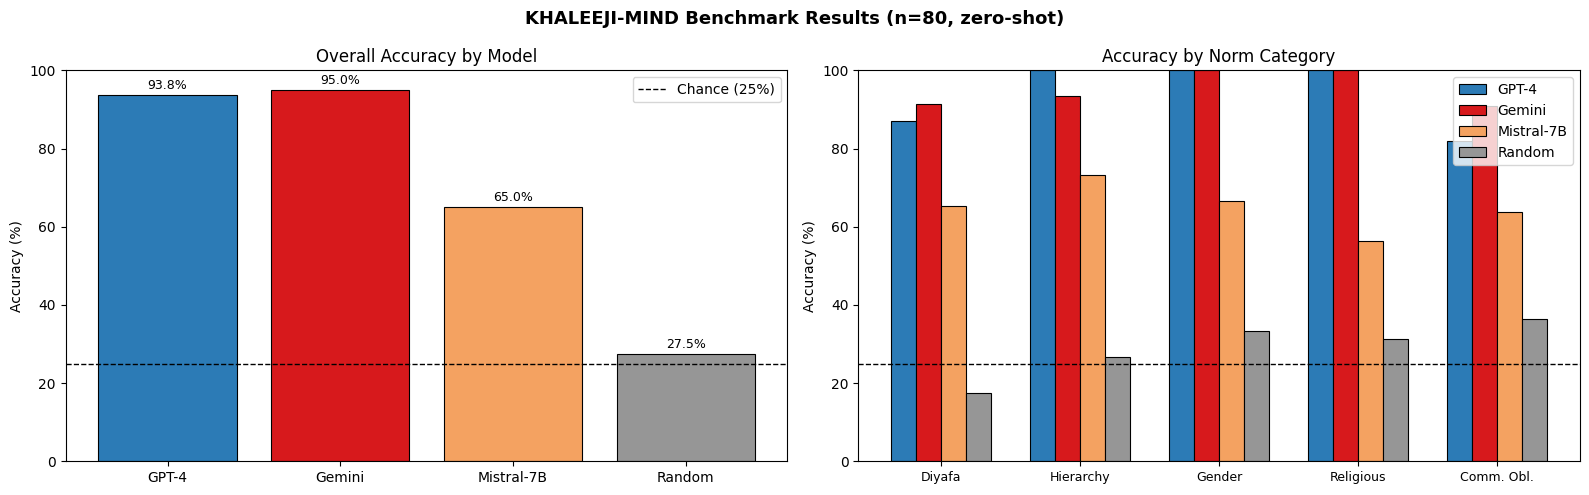

✅ Figure saved as khaleeji_mind_results.png


In [ ]:
import matplotlib.pyplot as plt

MODELS     = ["GPT-4", "Gemini", "Mistral-7B", "Random"]
COLORS     = ["#2c7bb6", "#d7191c", "#f4a261", "#969696"]
CAT_LABELS = ["Diyafa", "Hierarchy", "Gender", "Religious", "Comm. Obl."]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("KHALEEJI-MIND Benchmark Results (n=80, zero-shot)", fontsize=13, fontweight="bold")

# ── Plot 1: Overall accuracy by model ────────────────────────
overall_acc = [all_results[all_results.model == m]["is_correct"].mean() * 100 for m in MODELS]
bars = axes[0].bar(MODELS, overall_acc, color=COLORS, edgecolor="black", linewidth=0.8)
axes[0].axhline(25, color="black", linestyle="--", linewidth=1, label="Chance (25%)")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Overall Accuracy by Model")
axes[0].set_ylim(0, 100)
axes[0].legend()
for bar, v in zip(bars, overall_acc):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 1.5,
                 f"{v:.1f}%", ha="center", fontsize=9)

# ── Plot 2: Per-category accuracy ─────────────────────────────
x     = range(len(CATS))
width = 0.18
for i, (model, color) in enumerate(zip(MODELS, COLORS)):
    m    = all_results[all_results.model == model]
    vals = [
        m[m.norm_category == c]["is_correct"].mean() * 100
        if len(m[m.norm_category == c]) > 0 else 0
        for c in CATS
    ]
    axes[1].bar(
        [xi + i * width for xi in x], vals, width,
        label=model, color=color, edgecolor="black", linewidth=0.8
    )

axes[1].axhline(25, color="black", linestyle="--", linewidth=1)
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy by Norm Category")
axes[1].set_xticks([xi + width * 1.5 for xi in x])
axes[1].set_xticklabels(CAT_LABELS, fontsize=9)
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig("khaleeji_mind_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure saved as khaleeji_mind_results.png")

## Step 9 — Error Analysis

### 9a — Western-Centric Error Rate

Measures how often a model's **wrong answers** specifically land on the **Western-centric distractor** option — the answer that reflects how a non-Khaleeji observer would misread the situation.

A high Western-centric error rate means the model is not just failing randomly; it is systematically defaulting to a Western cultural frame.

### 9b — Accuracy by Severity

Checks whether models perform worse on scenarios with **higher severity scores** — i.e., situations where the social norm violation is more serious and the cultural gap is larger.


In [ ]:
# ── 9a: Western-centric error rate ───────────────────────────
western_map = {row["id"]: row["western_letter"] for _, row in df.iterrows()}

all_results["western_error"] = all_results.apply(
    lambda r: (not r["is_correct"]) and
              (r["predicted"] == western_map.get(r["scenario_id"])),
    axis=1
)

print("Western-centric error rate (% of wrong answers choosing the Western distractor):")
print("-" * 60)
for model in ["GPT-4", "Gemini", "Mistral-7B", "Random"]:
    m     = all_results[all_results.model == model]
    wrong = m[~m["is_correct"]]
    if len(wrong) == 0:
        print(f"  {model:<15}: no errors")
        continue
    rate  = wrong["western_error"].mean() * 100
    count = int(wrong["western_error"].sum())
    print(f"  {model:<15}: {rate:.1f}%  ({count} of {len(wrong)} wrong answers were Western-centric)")

# ── 9b: Accuracy by ToM order ────────────────────────────────
print("\nAccuracy by ToM order:")
print("-" * 40)
for model in ["GPT-4", "Gemini", "Mistral-7B", "Random"]:
    m  = all_results[all_results.model == model]
    o1 = m[m.tom_order == 1]
    o2 = m[m.tom_order == 2]
    print(f"  {model:<15}: Order-1 = {acc(o1):.1f}%  (n={len(o1)})  |  Order-2 = {acc(o2):.1f}%  (n={len(o2)})")

# ── 9c: Accuracy by severity ──────────────────────────────────
print("\nAccuracy by severity level (zero-shot):")
print("-" * 55)
for model in ["GPT-4", "Gemini", "Mistral-7B"]:
    print(f"\n  {model}:")
    m = all_results[(all_results.model == model) & (all_results.condition == "zero_shot")]
    for sev in sorted(m["severity"].dropna().unique()):
        sub = m[m["severity"] == sev]
        print(f"    severity {int(sev)}: {acc(sub):.1f}%  (n={len(sub)})")

Western-centric error rate (% of wrong answers choosing the Western distractor):
------------------------------------------------------------
  GPT-4          : 40.0%  (2 of 5 wrong answers were Western-centric)
  Gemini         : 0.0%  (0 of 4 wrong answers were Western-centric)
  Mistral-7B     : 35.7%  (10 of 28 wrong answers were Western-centric)
  Random         : 15.5%  (9 of 58 wrong answers were Western-centric)

Accuracy by ToM order:
----------------------------------------
  GPT-4          : Order-1 = 92.7%  (n=41)  |  Order-2 = 94.9%  (n=39)
  Gemini         : Order-1 = 95.1%  (n=41)  |  Order-2 = 94.9%  (n=39)
  Mistral-7B     : Order-1 = 68.3%  (n=41)  |  Order-2 = 61.5%  (n=39)
  Random         : Order-1 = 24.4%  (n=41)  |  Order-2 = 30.8%  (n=39)

Accuracy by severity level (zero-shot):
-------------------------------------------------------

  GPT-4:
    severity 0: 100.0%  (n=26)
    severity 2: 100.0%  (n=9)
    severity 3: 85.7%  (n=21)
    severity 4: 100.0%  (n=14

### Western-Centric Error, ToM, and Severity Analysis

The Western-centric error analysis measures how often a model’s wrong answers matched the option labeled as the likely Western or non-local misunderstanding. This helps distinguish between general mistakes and mistakes that specifically reflect culturally external interpretations.

Mistral-7B had the highest Western-centric error rate, with **35.7%** of its wrong answers choosing the Western distractor (**10 of 28 wrong answers**). GPT-4 had a **40.0%** Western-centric error rate, but this was only **2 of 5 wrong answers**, so it should be interpreted carefully because the total number of GPT-4 errors was very small. Gemini had **0.0%**, meaning none of its few errors matched the predefined Western distractor. The random baseline had **15.5%**.

The ToM-order breakdown shows that GPT-4 and Gemini remained relatively stable across first-order and second-order tasks. GPT-4 scored **92.7%** on first-order and **94.9%** on second-order tasks, while Gemini scored **95.1%** and **94.9%** respectively. Mistral-7B dropped from **68.3%** on first-order to **61.5%** on second-order tasks, suggesting that layered belief reasoning is harder for the smaller model.

The severity analysis shows that GPT-4 and Gemini answered all severity-0 and severity-2 scenarios correctly, but both dropped to **80.0%** on severity-5 cases. Mistral-7B was lower overall and performed weakest on severity-5 cases at **50.0%**.

Overall, these results show that larger models are highly accurate but still make occasional errors on socially delicate high-severity cases. Mistral-7B is less accurate overall and more likely to choose culturally external interpretations when it fails.

## Step 10 — Norm-in-Context Diagnostic

A deeper look at the zero-shot vs norm-in-context gap, broken down by norm category for all three models.

- A **large positive boost** suggests the model lacked or failed to retrieve the relevant cultural knowledge but could apply it once given. This is Mistral-7B's profile (**+15.0 pp overall**).
- A **small boost** suggests the model already inferred most of the relevant cultural context from the scenario. This is GPT-4 (**+2.5 pp**) and Gemini (**+1.2 pp**)'s profile.

The spot-check at the end shows individual failures for each model under norm-in-context, revealing which categories and which Western distractors each model keeps choosing even after being given the correct cultural context.


In [ ]:
# ── Zero-shot vs Norm-in-context comparison ──────────────────
print("=" * 72)
print("ZERO-SHOT vs NORM-IN-CONTEXT ACCURACY")
print("(Large boost → knowledge gap | Small boost → bias / reasoning failure)")
print("=" * 72)
print(f"{'Model':<15} {'Zero-Shot':>10} {'Norm-Context':>13} {'Boost':>8} {'Interpretation':>22}")
print("-" * 72)

for model in ["GPT-4", "Gemini", "Mistral-7B"]:
    zs    = all_results[(all_results.model == model) & (all_results.condition == "zero_shot")]["is_correct"].mean() * 100
    nc    = norm_results[norm_results.model == model]["is_correct"].mean() * 100
    boost = nc - zs
    interp = "Knowledge gap" if boost > 10 else "Bias / reasoning failure"
    print(f"{model:<15} {zs:>9.1f}%  {nc:>12.1f}%  {boost:>+7.1f}%  {interp:>22}")

print("=" * 72)

# ── Per-category norm boost ───────────────────────────────────
print("\nNorm-context boost by category (+ = norm context helped):")
print("-" * 60)
for model in ["GPT-4", "Gemini", "Mistral-7B"]:
    print(f"\n  {model}:")
    for cat in CATS:
        zs = all_results[
            (all_results.model == model) & (all_results.condition == "zero_shot") &
            (all_results.norm_category == cat)
        ]["is_correct"].mean() * 100
        nc = norm_results[
            (norm_results.model == model) & (norm_results.norm_category == cat)
        ]["is_correct"].mean() * 100
        boost = nc - zs
        bar   = "+" * int(abs(boost) // 5) if boost > 0 else "-" * int(abs(boost) // 5)
        print(f"    {cat:<28} {zs:.1f}% → {nc:.1f}%  ({boost:+.1f}%)  {bar}")

ZERO-SHOT vs NORM-IN-CONTEXT ACCURACY
(Large boost → knowledge gap | Small boost → bias / reasoning failure)
Model            Zero-Shot  Norm-Context    Boost         Interpretation
------------------------------------------------------------------------
GPT-4                93.8%          96.2%     +2.5%  Bias / reasoning failure
Gemini               95.0%          96.2%     +1.2%  Bias / reasoning failure
Mistral-7B           65.0%          80.0%    +15.0%           Knowledge gap

Norm-context boost by category (+ = norm context helped):
------------------------------------------------------------

  GPT-4:
    diyafa                       87.0% → 91.3%  (+4.3%)  
    hierarchy                    100.0% → 100.0%  (+0.0%)  
    gender_interaction           100.0% → 100.0%  (+0.0%)  
    religious_observance         100.0% → 100.0%  (+0.0%)  
    community_obligation         81.8% → 90.9%  (+9.1%)  +

  Gemini:
    diyafa                       91.3% → 100.0%  (+8.7%)  +
    hierarchy  


### Zero-Shot vs Norm-in-Context Comparison

This comparison tests whether model accuracy improves when the relevant Emirati cultural norm is explicitly provided before the question. A large improvement suggests a **cultural knowledge gap**, while a small improvement suggests that the model already had access to the relevant cultural knowledge and that remaining errors may come from reasoning, ambiguity, or answer-option confusion.

**GPT-4** improved from **93.8%** in zero-shot to **96.2%** with norm-in-context prompting, a gain of **+2.5 percentage points**. Since its zero-shot performance was already very high, the small boost suggests that GPT-4 usually inferred the cultural context correctly without needing explicit explanation.

**Gemini** improved only slightly, from **95.0%** to **96.2%**, a gain of **+1.2 percentage points**. This suggests that explicit norm context did not substantially change its performance, meaning Gemini already handled most cultural cues in the zero-shot setting.

**Mistral-7B** showed the largest improvement, rising from **65.0%** to **80.0%**, a boost of **+15.0 percentage points**. This indicates a stronger cultural knowledge gap: when Emirati سنع was made explicit, Mistral-7B became much better at identifying the correct interpretation.

At the category level, Mistral-7B benefited strongly from norm context, especially in categories such as hierarchy, community obligation, and diyafa.

Overall, norm-in-context prompting helped Mistral-7B the most. This supports the idea that smaller models struggle mainly because they lack or fail to retrieve the relevant Emirati cultural knowledge, while frontier models mostly fail only on subtle or ambiguous cases.

In [ ]:
# ── Spot-check: norm-in-context failures for all models ───────
norm_map = {row["id"]: row["norm_prompt"] for _, row in df.iterrows()}

norm_by_model = {
    "GPT-4":      norm_gpt4,
    "Gemini":     norm_gemini,
    "Mistral-7B": norm_mistral,
}

for model_name, norm_df in norm_by_model.items():
    failures = norm_df[~norm_df["is_correct"]].head(15)

    print(f"\n{'='*75}")
    print(f"{model_name} norm-in-context failures — what did it answer?")
    print(f"{'='*75}")
    print(f"{'ID':<12} {'Correct':>8} {'Predicted':>10} {'Western?':>10} {'Severity':>9} {'Category':<25}")
    print("-" * 75)

    for _, row in failures.iterrows():
        is_western = row["predicted"] == western_map.get(row["scenario_id"])
        sev_val    = df[df["id"] == row["scenario_id"]]["severity"].values
        sev_str    = str(int(sev_val[0])) if len(sev_val) > 0 else "?"
        print(
            f"{row['scenario_id']:<12} {row['correct']:>8} {str(row['predicted']):>10} "
            f"{'YES' if is_western else 'no':>10} {sev_str:>9} {row['norm_category']:<25}"
        )

    if len(failures) > 0:
        western_fail_rate = failures.apply(
            lambda r: r["predicted"] == western_map.get(r["scenario_id"]), axis=1
        ).mean() * 100
        print(f"\nWestern-centric rate among failures: {western_fail_rate:.1f}%")

        print(f"\nFull example of a {model_name} norm-in-context failure:")
        print("=" * 62)
        fail_id  = failures.iloc[0]["scenario_id"]
        fail_row = df[df["id"] == fail_id].iloc[0]
        print(f"Scenario ID   : {fail_id}")
        print(f"Correct answer: {fail_row['correct']}")
        print(f"{model_name} answered: {failures.iloc[0]['predicted']}")
        print(f"Western distractor letter: {western_map.get(fail_id)}")
        print(f"Severity: {fail_row['severity']}")
        print(f"\nNorm prompt sent:\n{fail_row['norm_prompt']}")


GPT-4 norm-in-context failures — what did it answer?
ID            Correct  Predicted   Western?  Severity Category                 
---------------------------------------------------------------------------
KM_D07              A          C         no         3 diyafa                   
KM_D11              B          A         no         5 diyafa                   
KM_C3               D          B         no         5 community_obligation     

Western-centric rate among failures: 0.0%

Full example of a GPT-4 norm-in-context failure:
Scenario ID   : KM_D07
Correct answer: A
GPT-4 answered: C
Western distractor letter: B
Severity: 3

Norm prompt sent:
Cultural context: Customary Emirati hosting includes small acts of deference by the host. When food is ready, the host may remain standing until the guests move toward the meal and take their seats. The phrase "the food is ready" is not only information; it functions as a cue that guests should begin moving promptly. By continuing the c

### Norm-in-Context Failure Analysis

Norm-in-context prompting reduced errors, but did not remove them completely. GPT-4 made **3 errors**, Gemini made **3 errors**, and Mistral-7B made **15 errors**. None of the GPT-4 or Gemini failures matched the predefined non-local distractor, suggesting that their remaining mistakes were more likely caused by subtle reasoning or answer-option ambiguity rather than culturally external assumptions.

Several repeated failures point to dataset refinement issues. **KM_D07** remained difficult for GPT-4 even with the cultural explanation, suggesting that the options about Mariam standing near the meal may be too close. **KM_C3** was missed by both GPT-4 and Gemini, because the distinction between “interference” and “waiting for formal invitation” overlaps conceptually. Gemini also missed **KM_H18** and **KM_H19**, where the options involve fine distinctions around elder respect and emotional interpretation.

Mistral-7B still struggled more, with a **46.7% non-local distractor rate among failures** and several blank predictions. Overall, norm-in-context prompting helps most with cultural knowledge gaps, but the remaining errors show that some benchmark items need clearer option separation.

## Step 11 — Save Results

Exports the full evaluation results table to CSV for further analysis and reporting.  
The saved file includes results from **zero-shot**, **chain-of-thought**, and **norm-in-context** conditions, plus the random baseline for zero-shot.

The exported table includes the main metadata and evaluation columns: `scenario_id`, `model`, `condition`, `language`, `norm_category`, `tom_order`, `severity`, `violated_norm`, `predicted`, `correct`, `is_correct`, `raw_response`, and `western_error`.


In [ ]:
# ── Save all evaluation results ───────────────────────────────
cot_df = pd.concat([cot_gpt4, cot_gemini, cot_mistral], ignore_index=True)

full_results = pd.concat([
    all_results,
    cot_df,
    norm_results
], ignore_index=True)

output_path = "khaleeji_mind_full_results.csv"
full_results.to_csv(output_path, index=False)


In [ ]:
# ── Final sanity checks before submission ─────────────────────

expected_models = ["GPT-4", "Gemini", "Mistral-7B"]
expected_conditions = ["zero_shot", "chain_of_thought", "norm_in_context"]

print("Rows:", len(full_results))
print("\nCondition breakdown:")
print(full_results.groupby(["model", "condition"]).size())

# Check total row count
assert len(full_results) == 800, "Expected 800 rows: 720 model rows + 80 random rows."

# Check each real model has 80 rows per condition
for model in expected_models:
    for condition in expected_conditions:
        n = len(full_results[
            (full_results["model"] == model) &
            (full_results["condition"] == condition)
        ])
        assert n == 80, f"{model} {condition} has {n} rows, expected 80."

# Check Random only appears in zero-shot
random_conditions = full_results[full_results["model"] == "Random"]["condition"].unique()
assert list(random_conditions) == ["zero_shot"], "Random should only appear in zero-shot."

# Check no missing predictions for real models
real_model_results = full_results[full_results["model"] != "Random"]
missing_preds = real_model_results["predicted"].isna().sum()
print("\nMissing predictions:", missing_preds)

print("\n✅ Final sanity checks passed.")

Rows: 800

Condition breakdown:
model       condition       
GPT-4       chain_of_thought    80
            norm_in_context     80
            zero_shot           80
Gemini      chain_of_thought    80
            norm_in_context     80
            zero_shot           80
Mistral-7B  chain_of_thought    80
            norm_in_context     80
            zero_shot           80
Random      zero_shot           80
dtype: int64

Missing predictions: 0

✅ Final sanity checks passed.


### Final Sanity Check Analysis

We ran this sanity check to make sure the final results file is complete and reproducible before using it in the report. This step verifies that every model was evaluated on every required scenario and that no rows or predictions are missing.

The final results table contains **800 rows**, which matches the expected output: 80 scenarios evaluated across three prompt conditions for GPT-4, Gemini, and Mistral-7B, plus the 80-row random baseline for zero-shot. Each model-condition pair has exactly **80 rows**, confirming that no evaluation condition is missing or duplicated. There are also **0 missing predictions**, meaning all model outputs were successfully parsed into answer labels. Overall, the sanity check confirms that the results file is complete and ready for analysis/reporting.

In [ ]:

# ── Prompting condition comparison table ──────────────────────

results = full_results.copy()

# Remove Random because Random only exists for zero-shot
model_results = results[results["model"] != "Random"]

acc_table = (
    model_results
    .groupby(["condition", "model"])["is_correct"]
    .mean()
    .mul(100)
    .round(1)
    .unstack()
)

# Add theoretical chance baseline
acc_table["Chance baseline"] = 25.0

acc_table



model,GPT-4,Gemini,Mistral-7B,Chance baseline
condition,,,,
chain_of_thought,93.8,96.2,70.0,25.0
norm_in_context,96.2,96.2,80.0,25.0
zero_shot,93.8,95.0,65.0,25.0


### Accuracy Table Analysis

This table compares model accuracy across the three prompting conditions: zero-shot, chain-of-thought, and norm-in-context. The chance baseline is **25.0%**, because each question has four answer choices.

GPT-4 performs strongly across all conditions. It scores **93.8%** in zero-shot and remains at **93.8%** with chain-of-thought, showing that CoT did not improve its overall accuracy. However, GPT-4 improves to **96.2%** with norm-in-context prompting, suggesting that explicit Emirati cultural context helped resolve some remaining errors.

Gemini has the highest zero-shot score at **95.0%** and improves slightly to **96.2%** under both chain-of-thought and norm-in-context prompting. This suggests that Gemini already captures most cultural cues from the scenario alone, with only a small benefit from additional prompting.

Mistral-7B shows the clearest improvement across conditions. It rises from **65.0%** in zero-shot to **70.0%** with chain-of-thought, then to **80.0%** with norm-in-context prompting. This indicates that Mistral-7B benefits much more from explicit cultural grounding than the frontier models.

Overall, all models perform above the **25.0%** chance baseline, but the gap between frontier models and Mistral-7B remains large. Norm-in-context prompting is the strongest intervention, especially for Mistral-7B.

In [ ]:
# Accuracy by language and model
language_table = (
    full_results[full_results["model"] != "Random"]
    .groupby(["language", "model"])["is_correct"]
    .mean()
    .mul(100)
    .round(1)
    .unstack()
)

language_table

model,GPT-4,Gemini,Mistral-7B
language,,,
AR,97.2,94.4,73.6
BILINGUAL,91.0,94.9,75.6
EN,95.6,97.8,66.7


### Language-Based Accuracy Analysis

The language results show that Arabic scenarios were not harder overall. **GPT-4** performed best on Arabic-only items (**97.2%**) but lowest on bilingual items (**91.0%**). **Gemini** was strongest on English items (**97.8%**) and stayed high across all languages. **Mistral-7B** performed lower overall, but did best on bilingual (**75.6%**) and Arabic (**73.6%**) items, not English.

Overall, the main challenge is not translation alone, but culturally grounded reasoning across languages.

In [ ]:
# Accuracy by Theory of Mind order and model
tom_table = (
    full_results[full_results["model"] != "Random"]
    .groupby(["tom_order", "model"])["is_correct"]
    .mean()
    .mul(100)
    .round(1)
    .unstack()
)

tom_table

model,GPT-4,Gemini,Mistral-7B
tom_order,,,
1,94.3,95.9,74.0
2,94.9,95.7,69.2


### ToM-Order Accuracy Analysis

This table aggregates accuracy across all three prompting conditions, so the values differ from the zero-shot-only ToM breakdown reported in the final report.

Across all prompting conditions, GPT-4 and Gemini remain stable across first-order and second-order tasks. GPT-4 scores **94.3%** on first-order and **94.9%** on second-order tasks, while Gemini scores **95.9%** and **95.7%** respectively.

Mistral-7B drops from **74.0%** on first-order to **69.2%** on second-order tasks, suggesting that layered belief reasoning remains harder for the smaller model even when all prompting conditions are included.

The zero-shot-only ToM breakdown reported in the final report is: GPT-4 **92.7% / 94.9%**, Gemini **95.1% / 94.9%**, and Mistral-7B **68.3% / 61.5%**.




## How the Report Values Were Calculated

The report’s main results use the **zero-shot condition only**. I filtered the results to `condition == "zero_shot"` and calculated:

**accuracy = correct predictions / total questions**

Since there are **80 scenarios**, each model has 80 zero-shot predictions.

- **GPT-4:** 75/80 = **93.8%**
- **Gemini:** 76/80 = **95.0%**
- **Mistral-7B:** 52/80 = **65.0%**
- **Random baseline:** 22/80 = **27.5%**

The theoretical chance baseline is **25.0%** because each question has 4 answer choices.

For ToM order, I used the same zero-shot filter and grouped by `tom_order`:

- **GPT-4:** first-order 38/41 = **92.7%**, second-order 37/39 = **94.9%**
- **Gemini:** first-order 39/41 = **95.1%**, second-order 37/39 = **94.9%**
- **Mistral-7B:** first-order 28/41 = **68.3%**, second-order 24/39 = **61.5%**

Any later table that combines zero-shot, chain-of-thought, and norm-in-context may show different values because it answers a different question.

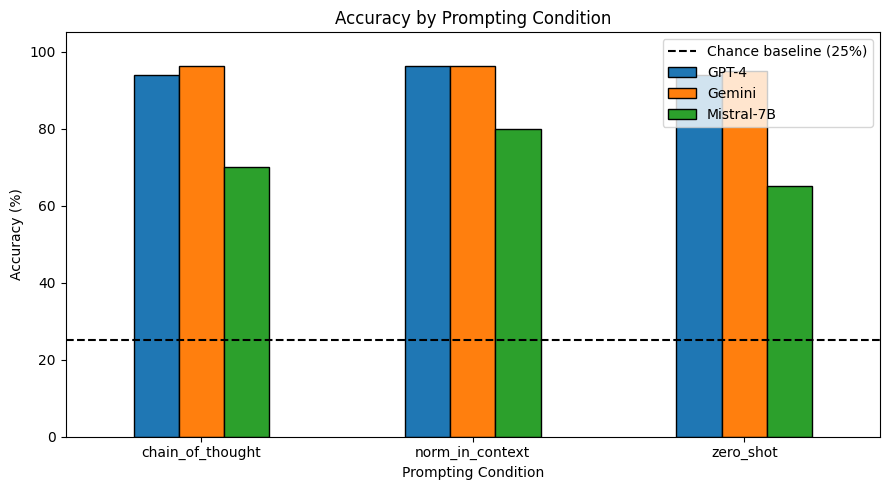

In [ ]:
# ── Plot accuracy by prompting condition ──────────────────────
import matplotlib.pyplot as plt
plot_table = acc_table.drop(columns=["Chance baseline"])

ax = plot_table.plot(kind="bar", figsize=(9, 5), edgecolor="black")

plt.axhline(25, linestyle="--", color="black", label="Chance baseline (25%)")

plt.title("Accuracy by Prompting Condition")
plt.ylabel("Accuracy (%)")
plt.xlabel("Prompting Condition")
plt.ylim(0, 105)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()

plt.savefig("khaleeji_mind_prompting_conditions.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
print(f"✅ Saved {len(full_results)} rows to '{output_path}'")
print(f"\nCondition breakdown:")
print(full_results.groupby(["model","condition"]).size().to_string())
print(f"\nColumns: {full_results.columns.tolist()}")
print("\nFirst 5 rows:")
full_results.head()

✅ Saved 800 rows to 'khaleeji_mind_full_results.csv'

Condition breakdown:
model       condition       
GPT-4       chain_of_thought    80
            norm_in_context     80
            zero_shot           80
Gemini      chain_of_thought    80
            norm_in_context     80
            zero_shot           80
Mistral-7B  chain_of_thought    80
            norm_in_context     80
            zero_shot           80
Random      zero_shot           80

Columns: ['scenario_id', 'model', 'condition', 'language', 'norm_category', 'tom_order', 'severity', 'violated_norm', 'predicted', 'correct', 'is_correct', 'raw_response', 'western_error']

First 5 rows:


,scenario_id,model,condition,language,norm_category,tom_order,severity,violated_norm,predicted,correct,is_correct,raw_response,western_error
0,KM_C8,Random,zero_shot,EN,community_obligation,1,4,Arriving unannounced during afternoon rest time.,A,C,False,NaN,True
1,KM_D02,Random,zero_shot,EN,diyafa,1,0,Misreading standard Emirati guest reception as...,A,D,False,NaN,True
2,KM_D27,Random,zero_shot,EN,diyafa,2,4,Filling an elder’s qahwa cup too much and mist...,C,A,False,NaN,False
3,KM_D04,Random,zero_shot,EN,diyafa,2,3,Misreading oud or dukhoon after the meal as co...,B,C,False,NaN,True
4,KM_D05,Random,zero_shot,EN,diyafa,1,0,Correctly reading the qahwa cup gestures for r...,B,B,True,NaN,False


### Full Results Export

The final evaluation results were saved to `khaleeji_mind_full_results.csv` with **800 rows**. This matches the full setup: 80 scenarios evaluated across three conditions for GPT-4, Gemini, and Mistral-7B, plus the Random baseline evaluated only in the zero-shot condition.

The condition breakdown confirms that every model-condition pair contains exactly **80 results**, so no scenarios are missing or duplicated. The Random baseline appears only under zero-shot because it does not use prompting, reasoning, or cultural context.

The exported file preserves all key analysis columns, including `scenario_id`, `model`, `condition`, `language`, `norm_category`, `tom_order`, `severity`, `violated_norm`, `predicted`, `correct`, `is_correct`, `raw_response`, and `western_error`. This confirms that the file is complete and ready for visualization, error analysis, and reporting.

## Known Issues & Next Steps

### Known Issues
- **Single annotator:** inter-annotator agreement could not be computed because the dataset was written and validated by one author.
- **Jais evaluation deferred:** Jais could not be evaluated at submission time due to HuggingFace/API access issues. Mistral-7B-Instruct-v0.1 was used instead as the open-source baseline.
- **Non-local distractor matching:** the heuristic for identifying distractor-letter matches may occasionally fail when answer options are very short or semantically close.
- **Answer-option ambiguity:** some errors, especially in KM_D07, KM_C3, KM_H18, and KM_H19, suggest that a few options need clearer separation.

### Next Steps
- Expand the dataset to **150+ scenarios** with more adversarial examples.
- Add validation from at least **three native Gulf Arabic annotators** and compute inter-annotator agreement.
- Evaluate **Jais-13B** as an Arabic-native baseline.
- Add **3-shot and 5-shot prompting** conditions.
- Conduct a small human baseline study with Emirati participants.
- Release the dataset and benchmark publicly after further validation.